<a href="https://colab.research.google.com/github/lauratpaes/Anna-Clara-_-Laura_-Lavinia/blob/main/tarefa11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Probabilidade aplicada à Biologia: variáveis aleatórias e modelos probabilísticos**

####Anna Clara Belmiro Tonial, n° USP 17097091

####Laura Tavares Paes, n° USP 17097601

####Lavínia Ramos Lourenço, n° USP 17081100

###**Sumário**
#####1. Variável aleatória
#####2. Variáveis aleatórias discreta e contínua
#####3. Modelo de Bernoulli
#####4. Modelo Binomial
#####5. Modelo de Poisson
#####6. Comparativo entre os modelos probabilísticos

####**1. Variável aleatória**

#####Uma variável aleatória $X$ é uma função que associa um número real a cada resultado possível do espaço amostral $S$ de um experimento. Este conceito é impotante, pois quando realizamos um experimento probabilístico, os resultados brutos observados raramente se apresentam de forma pronta para o cálculo algébrico. Eles podem ser sequências de caras e coroas, descrições qualitativas de uma comunidade de animais (animais migratórios ou não-migratórios), curvas de temperatura em termógrafos ou registros de velocidade de um leopardo.

In [ ]:
# Importação de banco de dados real (confira origem completa em "Referências" no arquivo README.md).

import pandas as pd
df = pd.read_excel('tarefa11aves.xlsx')
df.head(6)

,Species3,Family3,Order3,Total.individuals,Female,Male,Unknown,Complete.measures,Beak.Length_Culmen,Beak.Length_Nares,...,Migration,Trophic.Level,Trophic.Niche,Primary.Lifestyle,Min.Latitude,Max.Latitude,Centroid.Latitude,Centroid.Longitude,Range.Size,Species.Status
0,Abeillia abeillei,Trochilidae,Apodiformes,5,2,3,0,4,13.0,9.5,...,1.0,Herbivore,Nectarivore,Aerial,12.78,19.77,15.29,-89.792123,144610.40,Extant
1,Abroscopus albogularis,Sylviidae,Passeriformes,5,2,3,0,4,9.0,4.9,...,1.0,Carnivore,Invertivore,Insessorial,14.97,31.56,24.78,105.573934,1704650.60,Extant
2,Abroscopus schisticeps,Sylviidae,Passeriformes,4,3,1,0,4,9.0,4.7,...,1.0,Carnivore,Invertivore,Insessorial,20.19,31.12,26.70,95.584554,909217.05,Extant
3,Abroscopus superciliaris,Sylviidae,Passeriformes,5,2,3,0,4,12.3,7.4,...,1.0,Carnivore,Invertivore,Insessorial,-8.11,28.81,9.89,105.198587,2493437.47,Extant
4,Aburria aburri,Cracidae,Galliformes,12,6,6,0,4,37.1,16.6,...,1.0,Herbivore,Frugivore,Insessorial,-13.43,11.15,-2.79,-75.233396,139314.36,Extant
5,Acanthagenys rufogularis,Meliphagidae,Passeriformes,17,5,12,0,4,25.7,11.3,...,1.0,Herbivore,Omnivore,Insessorial,-38.86,-16.14,-27.10,133.984452,5976565.20,Extant


#####Por exemplo, nesta coletânea de informações referentes a uma série de espécies de dados, pode-se obter várias variáveis aletórias, dependendo do objetivo do estatístico.

#####Suponha que queira realizar de experimento sortear aleatoriamente uma espécie de ave da base de dados. Nosso objetivo é focado na ordem taxonômica *Passeriformes*, então, ao sortear uma espécie, pode-se obter uma espécie da ordem *Passeriformes* ou não pertencente à ordem *Passeriformes*. Dessa forma, temos que:

##### Variável aleatória $X$ = {1 caso a espécie seja *Passeriformes*; 2 caso a espécie não seja *Passeriformes*}

##### Repare que nossa variável é de caráter qualitativo, portanto, deve ser "traduzida" em um número para pode ser trabalhada em termos de cálculo. Assim, definimos que *Passeriformes* seja 1 e não-Passeriformes seja 2.

#####Exemplo. Caso a espécie sorteada seja a *Abeillia abeillei* (linha 0), teremos que $X$ = (2), pois esta espécie não é *Passeriformes*. No entanto, caso a espécie *Abroscopus albogularis* (linha 1) seja sorteada, então teremos que $X$ = 1, pois esta espécie pertence à *Passeriformes*.

####**2. Variáveis aleatórias discreta e contínua**

#####A classificação de uma variável aleatória depende intrinsecamente da natureza do seu espaço amostral associado $S$. A teoria estabelece duas categorias fundamentais:

#####- **2.1 Variáveis aleatórias discretas**: Ocorrem quando o espaço amostral associado é finito ou infinito numerável (contável). Um exemplo clássico énúmero de caras em quatro lançamentos de uma moeda ($S_2 = \{0, 1, 2, 3, 4\}$).

####**|_Exemplos de variáveis aleatórias discretas:**
* Número de fêmeas por espécie: se uma espécie for sorteada aleatoriamente no nosso banco de dados de aves e queiramos saber o número de fêmeas registradas na amostragem, o conjunto do espaço amostral só poderá ser composto por números inteiros finitos e contáveis, já que não é possível existir, por exemplo, 1.5 fêmeas.

* Número de indivíduos não-sexuados mensurados por espécie: no nosso banco de dados, há uma quantidade de indivíduos amostrados para cada espécies, os quais são clasificados por sexo. No entanto, há alguns que ficaram sem classificação no momento de coleta. Dessa forma, esta informação pode também ser classificada em uma variável aleatória discreta, já que seu espaço amostral é um conjunto contável de números inteiros.

* Contagem de comportamento migratório em uma amostra de aves: observe que nosso banco de dados possui uma coluna de comportamento migratório, em que 1 representa aves não-migratórias, 2 representa aves parcialmente migratórias e 3 representa aves migratórias. Logo, veja que, caso selecionássemos uma amostra de 20 espécies, o espaço amostral para a variável de migração seria composta pelos números 1, 2 e 3, que são finitos e contáveis.

#####- **2.2 Variáveis aleatórias contínuas:** Ocorrem quando o espaço amostral é infinito não-numerável, compreendendo intervalos contínuos da reta real.

####**|_Exemplos de variáveis aleatórias contínuas:**
* Comprimento do bico de uma amostra de aves: se selecionarmos uma espécie de ave aleatoriamente da base de dados e medirmos o comprimento do culmen (parte superior do bico), a variável aleatória seria contínua. Isso porque o comprimento do bico pode assumir qualquer valor real dentro de um intervalo, como 10.5 mm, 10.51 mm, 10.512 mm, etc., e não apenas valores inteiros. Assim, o espaço amostral seria um intervalo da reta real.

* Massa corporal das aves amostradas: da mesma forma, ao sortear uma espécie aleatoriamente e registrar sua massa corporal média, a variável aleatória massa corporal é contínua. A massa pode variar em frações muito pequenas, por exemplo, 20.3 gramas, 20.35 gramas, 20.358 gramas, não estando restrita a valores discretos e contáveis. O espaço amostral também seria um intervalo da reta real.

* Tamanho da área de ocorrência da espécie de ave: se considerarmos o tamanho da área de ocorrência de uma espécie selecionada aleatoriamente, essa variável aleatória também seria contínua. O tamanho de uma área geográfica pode ser medido em qualquer valor dentro de um contínuo, por exemplo, 1500.25 km² e 1500.257 km², e não apenas em números inteiros. O espaço amostral é um intervalo de valores possíveis para a área.

####**3. Modelo de Bernoulli**


#####O modelo de Bernoulli é um dos modelos probabilísticos mais simples e fundamentais, descrevendo um experimento aleatório com apenas dois resultados possíveis: sucesso ou fracasso. Cada execução desse experimento é chamada de 'ensaio de Bernoulli'. Além disso, é tido também que qualquer variável aleatória cujos únicos valores possíveis sejam 0 e 1 é denominada como variável aleatóris de Bernoulli.

#####**Exemplo biológico: Pertencimento à 0rdem *Passeriformes***

Para exemplificar o modelo de Bernoulli, usaremos o mesmo experimento em "Variáveis aleatórias", apenas adaptando seus valores de saída, ou seja,iremos selecionar aleatoriamente uma espécie do banco de dados e verificar se ela pertence à ordem *Passeriformes*.

*   **Sucesso:** A espécie selecionada pertence à ordem `Passeriformes`.
*   **Fracasso:** A espécie selecionada não pertence à ordem `Passeriformes`.
*   **Probabilidade de Sucesso (p):** É a proporção de espécies *Passeriformes* no nosso banco de dados.
*   **Variável Aleatória Associada (X):** Definimos $X = 1$ se o evento é um sucesso (espécie é *Passeriformes*) e $X = 0$ se é um fracasso (espécie não é *Passeriformes*).



In [ ]:
import numpy as np

# Cálculo da probabilidade de sucesso (p) do nosso banco de dados
passeriformes_count = df[df['Order3'] == 'Passeriformes'].shape[0]
total_species = df.shape[0]

p_success = passeriformes_count / total_species
print(f"Probabilidade de sucesso (p = espécie ser Passeriformes): {p_success:.4f}")
print(f"Probabilidade de fracasso (q = espécie não ser Passeriformes): {1 - p_success:.4f}\n")

# Simulação de 10 ensaios de Bernoulli
print("Simulação de 10 ensaios de Bernoulli (1 = Passeriformes, 0 = Não Passeriformes):")
simulated_trials = np.random.choice([0, 1], size=10, p=[1 - p_success, p_success])
print(simulated_trials)

# Simulação de um único ensaio para ilustrar a variável aleatória X
single_trial_result = np.random.choice([0, 1], size=1, p=[1 - p_success, p_success])[0]
print(f"\nResultado de um único ensaio de Bernoulli (X): {single_trial_result}")


Probabilidade de sucesso (p = espécie ser Passeriformes): 0.5970
Probabilidade de fracasso (q = espécie não ser Passeriformes): 0.4030

Simulação de 10 ensaios de Bernoulli (1 = Passeriformes, 0 = Não Passeriformes):
[0 1 1 0 1 0 1 0 0 0]

Resultado de um único ensaio de Bernoulli (X): 1


#####**Interpretação**

No nosso exemplo, a probabilidade p calculada representa a frequência relativa de espécies da ordem *Passeriformes* na sua base de dados. Um valor de p próximo a 1 indica que a maioria das espécies é *Passeriformes*, enquanto um valor próximo a 0 indica o contrário.

Cada número 1 na simulação de ensaios representa uma espécie selecionada aleatoriamente que é *Passeriformes* (sucesso). Cada 0 representa uma espécie que não é *Passeriformes* (fracasso).

O resultado de um X = 1 significa que a espécie sorteada naquele ensaio pertence à ordem *Passeriformes*, e um X = 0 significa que não pertence. Essa simulação nos ajuda a entender como, a longo prazo, a proporção de 'sucessos' (espécies *Passeriformes*) em uma grande série de ensaios individuais tenderá a se aproximar da probabilidade p que calculamos a partir do banco de dados.

Em um contexto biológico, esta abordagem é interessante para medir a diversidade taxonômica de uma amostragem, que neste caso foi aplicado à ordem de pássaros, mas poderia também ser utilizado para família ou filos quando trabalhamos com um ecossistema.

####**4. Modelo Binomial**

In [ ]:
# Importação de banco de dados sobre Trilobitas (confira origem completa em "Referências" no arquivo README.md).

import pandas as pd
df = pd.read_excel('Trilobitas atividade 11.xlsx', skiprows=17)
df.head(6)

,occurrence_no,record_type,reid_no,flags,collection_no,identified_name,identified_rank,identified_no,difference,accepted_name,accepted_rank,accepted_no,early_interval,late_interval,max_ma,min_ma,reference_no
0,10205,occ,NaN,NaN,592,Warburgella sp.,genus,NaN,NaN,Warburgella,genus,21405,Lochkovian,Pragian,419.62,410.62,60988
1,10206,occ,NaN,NaN,592,Proetida indet.,order,NaN,NaN,Proetida,order,21062,Lochkovian,Pragian,419.62,410.62,60988
2,10207,occ,NaN,NaN,592,? Phacopida indet.,order,NaN,NaN,Phacopida,order,21421,Lochkovian,Pragian,419.62,410.62,60988
3,10212,occ,NaN,NaN,593,Phacops sp.,genus,NaN,NaN,Phacops,genus,21701,Lochkovian,NaN,419.62,413.02,15806
4,10213,occ,NaN,NaN,593,Dalmanites sp.,genus,NaN,NaN,Dalmanites,genus,21523,Lochkovian,NaN,419.62,413.02,15806
5,10214,occ,NaN,NaN,593,Bronteus sp.,genus,20372.0,species not entered,Scutellum,genus,19684,Lochkovian,NaN,419.62,413.02,15806


### **4.1. Definição do Modelo Binomial**
O modelo Binomial é uma distribuição de probabilidade discreta que descreve o número de sucessos $X$ obtidos em um número fixo $n$ de ensaios ou observações independentes e idênticos.

A função de probabilidade é dada por:

$$P(X = k) = \binom{n}{k} p^k (1-p)^{n-k}$$

Onde:
- $n$: número fixo de observações ou ensaios.
- $k$: número de sucessos desejados.
- $p$: probabilidade de sucesso em cada ensaio.
- $1-p$: probabilidade de fracasso.

### **4.2 Aplicação Contextualizada**
- Os dados representam uma amostra de registros de fósseis do clado *Trilobita* do período Devoniano extraída da *Paleobiology Database (PBDB)*.
- **Ensaio:** Inspeção de cada registro fóssil da amostra.
- **Sucesso (1):** O fóssil pertencer ao gênero *Phacops*, gÊnero com os representantes mais abundantes e facilmente reconhecíveis.
- **Fracasso (0):** O fóssil pertencer a qualquer outro gênero do grupo *Trilobita*.

     RESULTADOS ESTATÍSTICOS DO MODELO BINOMIAL
• Número fixo de observações (n): 5974
• Sucessos observados do gênero Phacops (k): 264
• Probabilidade estimada de sucesso (p): 0.0442 (4.42%)
• Valor Médio Esperado E[X]: 264.00
• Variância Var[X]: 252.33
• Desvio Padrão: 15.89
• Probabilidade P(X = 264): 0.0251 (2.51%)


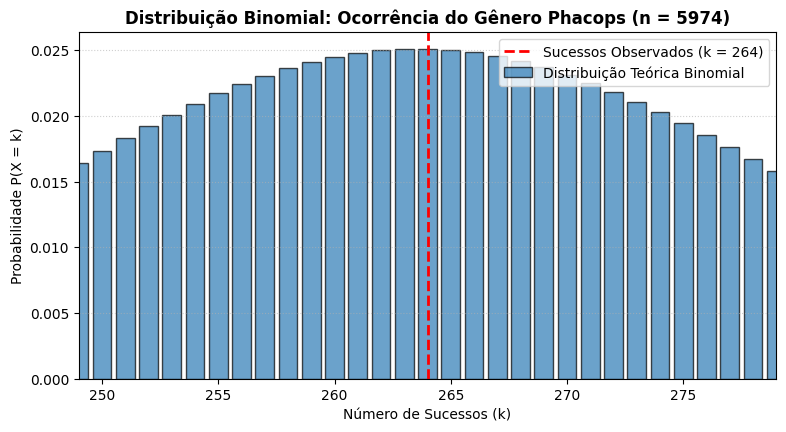

In [ ]:
# Gráfico: "Distribuição Binomial: Ocorrência do Gênero Phacops (n = 5974)" e definição dos resultados estatísticos do modelo binomial
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import binom

# 1. Criar a variável Binomial no DataFrame com base nos dados existentes no banco
# Sucesso (1) = Gênero 'Phacops'| Fracasso (0) = Outros gêneros de Trilobita
df["sucesso"] = (
    df["accepted_name"]
    .astype(str)
    .str.contains("Phacops", case=False, na=False)
    .astype(int)
)

# 2. Obter os parâmetros do modelo Binomial
n = len(df)  # Número fixo de observações/registros (n)
k = df["sucesso"].sum()  # Número de sucessos observados na amostra
p_estimado = k / n  # Probabilidade estimada de sucesso

# 3. Cálculos Teóricos do Modelo Binomial
media_esperada = n * p_estimado  # E[X] = n * p
variancia_esperada = n * p_estimado * (1 - p_estimado)  # Var(X) = n * p * (1 - p)
desvio_padrao = np.sqrt(variancia_esperada)

# Probabilidade exata de obter exatamente k sucessos
prob_exata = binom.pmf(k, n, p_estimado)

print("=" * 55)
print("     RESULTADOS ESTATÍSTICOS DO MODELO BINOMIAL")
print("=" * 55)
print(f"• Número fixo de observações (n): {n}")
print(f"• Sucessos observados do gênero Phacops (k): {k}")
print(
    f"• Probabilidade estimada de sucesso (p): {p_estimado:.4f} ({p_estimado*100:.2f}%)"
)
print(f"• Valor Médio Esperado E[X]: {media_esperada:.2f}")
print(f"• Variância Var[X]: {variancia_esperada:.2f}")
print(f"• Desvio Padrão: {desvio_padrao:.2f}")
print(f"• Probabilidade P(X = {k}): {prob_exata:.4f} ({prob_exata*100:.2f}%)")
print("=" * 55)

# 4. Construção do Gráfico da Distribuição Binomial
x = np.arange(0, n + 1)
pmf = binom.pmf(x, n, p_estimado)

plt.figure(figsize=(9, 4.5))
plt.bar(
    x,
    pmf,
    color="#2c7bb6",
    edgecolor="black",
    alpha=0.7,
    label="Distribuição Teórica Binomial",
)
plt.axvline(
    k,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Sucessos Observados (k = {k})",
)

# Ajuste do limite visual do gráfico ao redor do valor k
plt.xlim(max(0, k - 15), min(n, k + 15))
plt.title(
    f"Distribuição Binomial: Ocorrência do Gênero Phacops (n = {n})",
    fontsize=12,
    fontweight="bold",
)
plt.xlabel("Número de Sucessos (k)", fontsize=10)
plt.ylabel("Probabilidade P(X = k)", fontsize=10)
plt.legend()
plt.grid(axis="y", linestyle=":", alpha=0.6)
plt.show()

####**5. Modelo de Poisson**


#####O modelo de Poisson é uma distribuição de probabilidade discreta utilizada para representar o número de ocorrências de um evento em determinado intervalo de tempo, espaço ou outra unidade de observação. Seu principal parâmetro é λ (lambda), que representa a taxa média de ocorrência dos eventos no intervalo considerado.


#####**Exemplo biológico: Número de insetos capturados por armadilha**

Para exemplificar o modelo de Poisson, utilizaremos dados simulados que representam o número de insetos capturados por uma armadilha ao longo de 30 noites de observação. Consideraremos uma taxa média de captura de 4 insetos por noite ((\lambda = 4)), com o objetivo de calcular as probabilidades de ocorrência de diferentes quantidades de capturas.

**Evento de interesse:** Número de insetos capturados em uma armadilha durante uma noite.

**Intervalo de observação:** Uma noite, considerando cada noite como uma unidade de observação.

**Taxa média de ocorrência ((\lambda)):** 4 insetos por noite, valor adotado para o exemplo.

**Variável aleatória associada (X):** Número de insetos capturados em uma noite, podendo assumir valores inteiros não negativos (0, 1, 2, 3, ...).

Os dados simulados permitem comparar as frequências observadas com as probabilidades teóricas da distribuição de Poisson, possibilitando avaliar como o modelo representa a ocorrência de insetos nas condições consideradas.

Média de capturas por noite: 3.933333333333333
   Capturas  Frequência observada  Probabilidade teórica
0         0                     0                 0.0196
1         1                     2                 0.0770
2         2                     4                 0.1514
3         3                     6                 0.1986
4         4                     8                 0.1953
5         5                     5                 0.1536
6         6                     3                 0.1007
7         7                     1                 0.0566
8         8                     1                 0.0278
9         9                     0                 0.0122


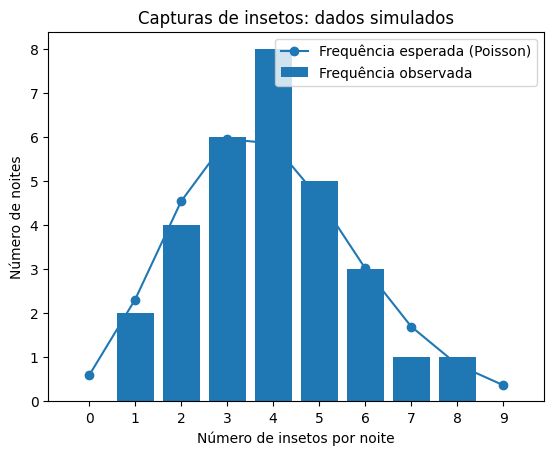

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import poisson

# Dados simulados de 30 noites
capturas = np.array([
    3, 5, 2, 4, 6, 3, 4, 5, 1, 4,
    7, 2, 3, 5, 4, 6, 3, 4, 2, 5,
    4, 3, 8, 1, 4, 6, 3, 5, 2, 4
])

# Média observada
lamb = capturas.mean()
print("Média de capturas por noite:", lamb)

# Frequência observada
valores = np.arange(0, 10)
frequencias = [
    np.sum(capturas == k) for k in valores
]

# Probabilidades teóricas de Poisson
probabilidades = poisson.pmf(valores, lamb)

# Tabela de resultados
tabela = pd.DataFrame({
    "Capturas": valores,
    "Frequência observada": frequencias,
    "Probabilidade teórica": probabilidades
})

print(tabela.round(4))

# Gráfico: frequência observada e esperada
plt.bar(valores, frequencias, label="Frequência observada")
plt.plot(
    valores,
    len(capturas) * probabilidades,
    "o-",
    label="Frequência esperada (Poisson)"
)
plt.xlabel("Número de insetos por noite")
plt.ylabel("Número de noites")
plt.title("Capturas de insetos: dados simulados")
plt.xticks(valores)
plt.legend()
plt.show()

#####**Interpretação**

No nosso exemplo, a taxa média λ=4 representa a quantidade média de insetos capturados por armadilha em uma noite. Esse valor é utilizado pelo modelo de Poisson para calcular a probabilidade de ocorrência de diferentes quantidades de capturas.

Cada valor observado no conjunto de dados representa o número de insetos capturados em uma noite. Por exemplo, um resultado igual a 3 indica que três insetos foram capturados naquela noite, enquanto um resultado igual a 0 indicaria que nenhum inseto foi capturado.

A distribuição de Poisson permite estimar a probabilidade de capturar uma quantidade específica de insetos em uma noite. Considerando λ=4, a probabilidade de capturar exatamente quatro insetos é de aproximadamente 19,54%. Isso significa que, sob as condições do modelo, espera-se que cerca de 19,54% das noites apresentem exatamente quatro capturas.

Em um contexto biológico, essa abordagem é útil para estudar a frequência de ocorrência de organismos em determinadas unidades de observação, como o número de insetos capturados por armadilha, o número de indivíduos encontrados em uma parcela ou o número de organismos presentes em uma amostra. Dessa forma, o modelo de Poisson permite representar e estimar a ocorrência desses eventos, desde que suas suposições sejam razoáveis para o cenário estudado.

#### **6. Comparativo dos modelos probabilísticos**


| Modelo Probabilístico | Fenômeno Representado                                     | Valores Possíveis        | Situação de Aplicação                                                                      | Exemplo Usado no Notebook                                        |
| :-------------------- | :-------------------------------------------------------- | :----------------------- | :----------------------------------------------------------------------------------------- | :--------------------------------------------------------------- |
| **Bernoulli**         | Resultado de um único ensaio com dois resultados (sucesso/fracasso) | {0, 1}                     | Experimentos com apenas dois resultados mutuamente exclusivos.                       | Uma espécie de ave ser ou não da ordem *Passeriformes*.   |
| **Binomial**          | Número de sucessos em um número fixo de ensaios Bernoulli independentes | {0, 1, ..., n}           | Contagem do número de sucessos em uma série de ensaios idênticos e independentes. | Número de fósseis do gênero *Phacops* em uma amostra de Trilobitas. |
| **Poisson**           | Número de ocorrências de um evento em um intervalo fixo de tempo/espaço | {0, 1, 2, ...}           | Modelagem de eventos raros que ocorrem com uma taxa média constante em um intervalo.   | Número de insetos capturados por armadilha em uma noite. |